In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
data_dir = "../data/removal_data_repl_interpol_6k"

## Inspect Metadata

In [3]:
df_summary = pd.read_csv("../data/beats_summary_frame.csv")
df_summary.shape

(240012, 14)

In [4]:
df_summary['subject'].nunique(), df_summary['subject'].max()

(20001, np.int64(20000))

In [5]:
df_all_meta = pd.read_csv("../data/exams.csv")
df_all_meta.head()

,exam_id,age,is_male,nn_predicted_age,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,timey,normal_ecg,trace_file
0,1169160,38,True,40.160484,False,False,False,False,False,False,523632,False,2.098628,True,exams_part13.hdf5
1,2873686,73,True,67.059440,False,False,False,False,False,False,1724173,False,6.657529,False,exams_part13.hdf5
2,168405,67,True,79.621740,False,False,False,False,False,True,51421,False,4.282188,False,exams_part13.hdf5
3,271011,41,True,69.750260,False,False,False,False,False,False,1737282,False,4.038353,True,exams_part13.hdf5
4,384368,73,True,78.873460,False,False,False,False,False,False,331652,False,3.786298,False,exams_part13.hdf5


In [6]:
df_meta_16 = df_all_meta[df_all_meta['trace_file'] == "exams_part16.hdf5"].copy()
df_meta_16.reset_index(drop=True, inplace=True)
df_meta_16.shape

(20000, 15)

In [7]:
df_meta_16.head()

,exam_id,age,is_male,nn_predicted_age,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,timey,normal_ecg,trace_file
0,1719487,36,True,48.075348,False,False,False,False,False,False,743857,False,1.049314,True,exams_part16.hdf5
1,1733991,66,False,40.656740,False,False,False,False,False,False,22622,NaN,NaN,False,exams_part16.hdf5
2,1801245,71,False,68.454320,False,False,False,False,False,False,825816,False,0.906849,False,exams_part16.hdf5
3,1805614,85,True,80.328300,False,False,False,False,False,False,1741484,NaN,NaN,False,exams_part16.hdf5
4,1718974,72,True,65.607850,False,False,False,False,False,False,995129,False,1.049314,False,exams_part16.hdf5


In [8]:
retained_subject_ids = df_summary[df_summary['retain_subject']]['subject'].values
df_meta_retained = df_meta_16[df_meta_16.index.isin(retained_subject_ids)].copy()

In [53]:
df_meta_retained.head()

,exam_id,age,is_male,nn_predicted_age,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,timey,normal_ecg,trace_file,pred_label
0,1719487,36,True,48.075348,False,False,False,False,False,False,743857,False,1.049314,True,exams_part16.hdf5,old
1,1733991,66,False,40.656740,False,False,False,False,False,False,22622,NaN,NaN,False,exams_part16.hdf5,young
2,1801245,71,False,68.454320,False,False,False,False,False,False,825816,False,0.906849,False,exams_part16.hdf5,neutral
3,1805614,85,True,80.328300,False,False,False,False,False,False,1741484,NaN,NaN,False,exams_part16.hdf5,neutral
4,1718974,72,True,65.607850,False,False,False,False,False,False,995129,False,1.049314,False,exams_part16.hdf5,neutral


In [55]:
df_summary.drop(columns='Unnamed: 0', inplace=True)
df_summary.head()

,subject,channel,n_peaks,inter_beat_sd,peaks,mode_n_peaks,mode_count,min_peak,max_peak,hr,avg_inter_beat_sd,retain_subject,new_subject_id
0,0,0,9.0,9.096703,[ 211 670 1118 1560 2002 2443 2885 3314 3743],9.0,10,211.0,3743.0,55.663204,9.104809,True,0.0
1,0,1,9.0,9.137833,[ 212 671 1119 1561 2004 2444 2886 3316 3744],9.0,10,212.0,3744.0,55.663204,9.104809,True,0.0
2,0,2,3.0,656.500000,[1123 1565 3320],9.0,10,1123.0,3320.0,55.663204,9.104809,True,0.0
3,0,3,9.0,9.124144,[ 211 670 1118 1560 2003 2444 2885 3315 3743],9.0,10,211.0,3743.0,55.663204,9.104809,True,0.0
4,0,4,9.0,9.096703,[ 210 669 1117 1559 2001 2443 2884 3313 3742],9.0,10,210.0,3742.0,55.663204,9.104809,True,0.0


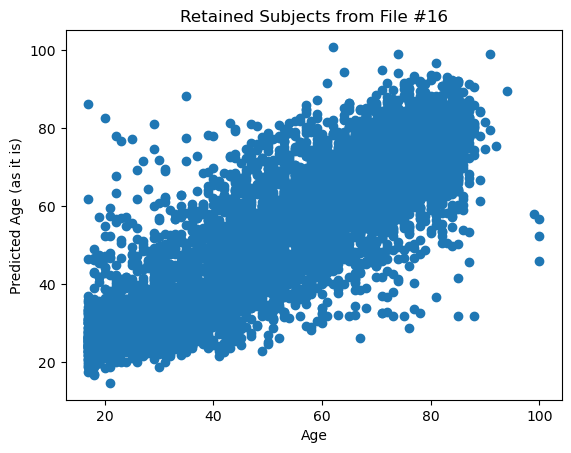

In [11]:
plt.title("Retained Subjects from File #16")
plt.xlabel("Age")
plt.ylabel("Predicted Age (as it is)")
plt.scatter(
    df_meta_retained['age'],
    df_meta_retained['nn_predicted_age'],
)
plt.show()

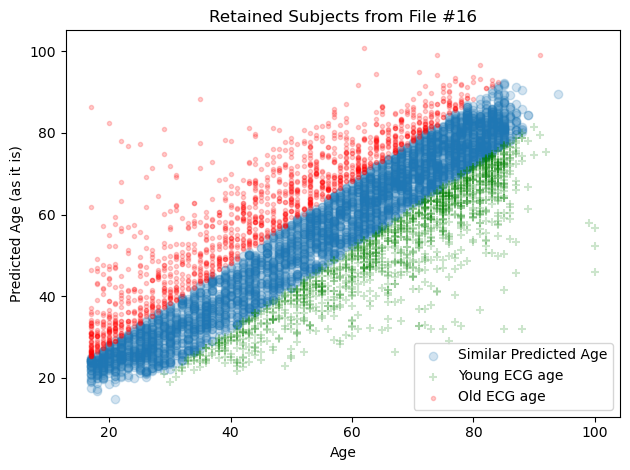

In [12]:
plt.title("Retained Subjects from File #16")
plt.xlabel("Age")
plt.ylabel("Predicted Age (as it is)")
young_filt = (df_meta_retained['age'] - df_meta_retained['nn_predicted_age'] >= 8)
as_is_filt = (abs(df_meta_retained['age'] - df_meta_retained['nn_predicted_age']) < 8)
old_filt = (df_meta_retained['nn_predicted_age'] - df_meta_retained['age'] >= 8)

plt.scatter(
    df_meta_retained[as_is_filt]['age'],
    df_meta_retained[as_is_filt]['nn_predicted_age'],
    label='Similar Predicted Age',
    alpha=0.2
)

plt.scatter(
    df_meta_retained[young_filt]['age'],
    df_meta_retained[young_filt]['nn_predicted_age'],
    label='Young ECG age',
    c='green',
    alpha=0.2,
    marker='+'
    
)

plt.scatter(
    df_meta_retained[old_filt]['age'],
    df_meta_retained[old_filt]['nn_predicted_age'],
    label='Old ECG age',
    c='red',
    alpha=0.2,
    marker='.'
)
plt.legend()
plt.tight_layout()
plt.savefig("selected_subjects_age_vs_orig_predicted.png")
plt.show()

In [13]:
df_meta_retained.loc[:, 'pred_label'] = None
df_meta_retained.loc[young_filt, 'pred_label'] = 'young'
df_meta_retained.loc[as_is_filt, 'pred_label'] = 'neutral'
df_meta_retained.loc[old_filt, 'pred_label'] = 'old'

In [14]:
df_meta_retained['pred_label'].value_counts()

pred_label
neutral    3403
old        1358
young      1283
Name: count, dtype: int64

In [15]:
df_meta_retained['normal_ecg'].value_counts()

normal_ecg
False    3259
True     2785
Name: count, dtype: int64

In [16]:
df = pd.read_csv(f"{data_dir}/all_subjects_and_pixels_12pixels_6k_sub.csv")
df.shape

(2115400, 5)

In [17]:
df_exam_ids = pd.read_csv("../data/average_beat_metadata.csv")
df_exam_ids.head()

,exam_id,data_arr_idx,start_beat,end_beat,channel_used
0,1750214,0,1893,2358,0
1,1688724,1,1928,2288,1
2,1771393,2,1939,2266,0
3,1793030,3,1934,2275,0
4,1717689,4,1973,2197,1


In [18]:
df_exam_ids.shape

(6044, 5)

In [38]:
subject_exam_id = {}
for idx, exam_id in zip(df_summary, df_exam_ids['exam_id']):
    subject_exam_id[idx] = exam_id

exam_id_age = {}
for exam_id, age in zip(df_all_meta['exam_id'].values, df_all_meta['age'].values):
    exam_id_age[exam_id] = age

print("number of subject ids in mapping")
print(len(subject_exam_id))


print("How many common subjects in replace metadata and average beat metadata:")
print(len(set(df['subject'].unique()).intersection(subject_exam_id.keys())))
print("\n")

print("The number of common exam_ids in both dictionaries:")
print(len(set(subject_exam_id.values()).intersection(set(exam_id_age.keys()))))

number of subject ids in mapping
6044
How many common subjects in replace metadata and average beat metadata:
6044


The number of common exam_ids in both dictionaries:
6044


In [19]:
for key, value in subject_exam_id.items():
    if value == 1750214:
        print(key, value)

0 1750214


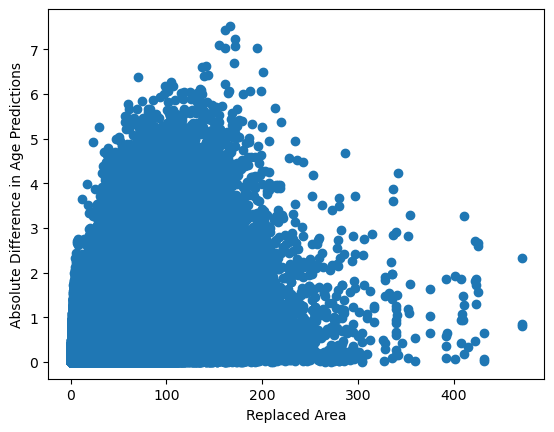

In [20]:
# Correlation of replaced area with diffrence in prediction
plt.xlabel("Replaced Area")
plt.ylabel("Absolute Difference in Age Predictions")
plt.scatter(df['replace_area'], abs(df['raw_prediction'] - df['replace_prediction']))
plt.show()

In [21]:
x_arr = [30, 47]

{0: 1750214,
 1: 1688724,
 2: 1771393,
 3: 1793030,
 4: 1717689,
 5: 1792764,
 6: 1799245,
 7: 1728365,
 8: 1775584,
 9: 1801756,
 10: 1694878,
 11: 1774628,
 12: 1725934,
 13: 1811097,
 14: 1686444,
 15: 1757296,
 16: 1780588,
 17: 1713817,
 18: 1803264,
 19: 1740480,
 20: 1819194,
 21: 1788791,
 22: 1689278,
 23: 1798593,
 24: 1692610,
 25: 1687762,
 26: 1698062,
 27: 1749428,
 28: 1701688,
 29: 1688188,
 30: 1732577,
 31: 1780373,
 32: 1695438,
 33: 1717795,
 34: 1717073,
 35: 1778718,
 36: 1772667,
 37: 1787451,
 38: 1709251,
 39: 1745054,
 40: 1797269,
 41: 1713483,
 42: 1783241,
 43: 1692118,
 44: 1798490,
 45: 1712493,
 46: 1753128,
 47: 1806803,
 48: 1712997,
 49: 1693020,
 50: 1717492,
 51: 1687844,
 52: 1811572,
 53: 1695956,
 54: 1718266,
 55: 1736228,
 56: 1806668,
 57: 1757945,
 58: 1764629,
 59: 1703477,
 60: 1747342,
 61: 1811206,
 62: 1699633,
 63: 1714714,
 64: 1781452,
 65: 1694924,
 66: 1733834,
 67: 1742906,
 68: 1775798,
 69: 1730802,
 70: 1702104,
 71: 1797741,
 7

In [40]:
pixel = 2048

dfp = df[df['start_pixel'] == pixel].copy()
dfp.loc[:, 'exam_id'] = dfp['subject'].map(subject_exam_id)
print(dfp['exam_id'].isin(subject_exam_id.values()).sum())
dfp.loc[:, 'age'] = dfp['exam_id'].map(exam_id_age)
dfp.head()


6044


,start_pixel,subject,raw_prediction,replace_prediction,replace_area,exam_id,age
894512,2048,0,41.992142,42.384125,69.600100,1750214,82
894513,2048,1,33.170807,33.608952,70.990715,1688724,44
894514,2048,2,36.380669,36.440895,48.039826,1771393,51
894515,2048,3,33.149220,34.046810,27.792915,1793030,28
894516,2048,4,38.721252,38.750412,34.933605,1717689,52


In [48]:
int(dfp['age'].isna().sum()) == 0, len(dfp)

(True, 6044)

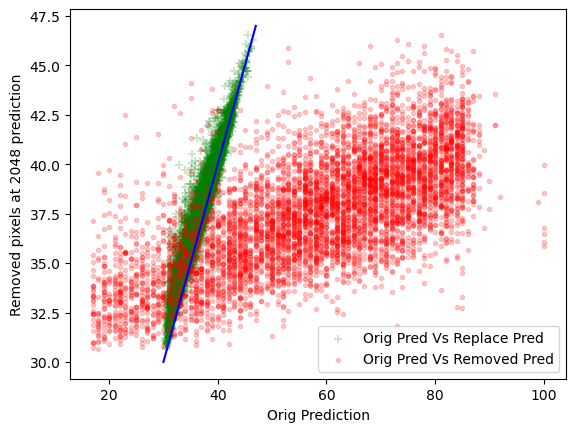

In [47]:
plt.scatter(
    dfp['raw_prediction'],
    dfp['replace_prediction'],
    c='green',
    alpha=0.2,
    marker='+',
    label='Orig Pred Vs Replace Pred'
)

# plt.scatter(
#     dfp['age'],
#     dfp['replace_prediction'],
#     c='red',
#     alpha=0.2,
#     marker='.',
#     label='Orig Pred Vs Removed Pred'
# )
plt.xlabel("Orig Prediction")
plt.ylabel(f"Removed pixels at {pixel} prediction")
plt.legend()
plt.plot(x_arr, x_arr, c='blue')
plt.show()

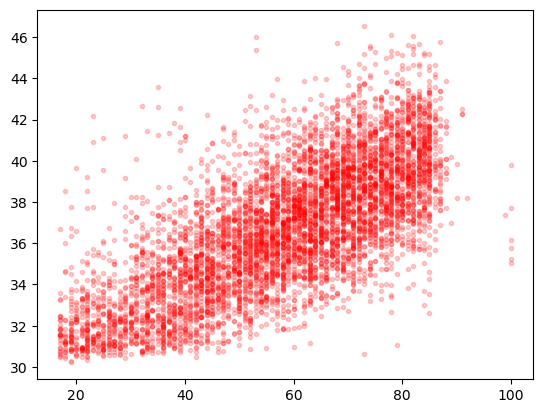

In [52]:
plt.scatter(
    dfp['age'],
    dfp['raw_prediction'],
    c='red',
    alpha=0.2,
    marker='.',
    label='Orig Pred Vs Removed Pred'
)


In [ ]:
df[~df.age.isna()]['subject'].nunique()

In [ ]:
pixel = 2048
plt.title("Retained Subjects from File #16; 12 pixels removed")
plt.xlabel("Raw Prediction")
plt.ylabel(f"Predicted Age (removed at {pixel})")
young_filt = (df['age'] - df['raw_prediction'] >= 8)
as_is_filt = (abs(df['age'] - df['raw_prediction']) < 8)
old_filt = (df['raw_prediction'] - df['age'] >= 8)

pixel_start_filt = (df['start_pixel'] == pixel)

plt.scatter(
    df[as_is_filt & pixel_start_filt]['age'],
    df[as_is_filt & pixel_start_filt]['replace_prediction'],
    label='Similar Predicted Age',
    alpha=0.2
)

plt.scatter(
    df[young_filt & pixel_start_filt]['age'],
    df[young_filt & pixel_start_filt]['replace_prediction'],
    label='Young ECG age',
    c='green',
    alpha=0.2,
    marker='+'
    
)

plt.scatter(
    df[old_filt & pixel_start_filt]['age'],
    df[old_filt & pixel_start_filt]['replace_prediction'],
    label='Old ECG age',
    c='red',
    alpha=0.2,
    marker='.'
)
plt.legend()
plt.tight_layout()
plt.savefig("selected_subjects_age_vs_orig_predicted.png")
plt.show()

In [ ]:
pixel = 2048
plt.title("Retained Subjects from File #16; 12 pixels removed")
plt.xlabel("Raw Prediction")
plt.ylabel(f"Predicted Age (removed at {pixel})")
young_filt = (df['age'] - df['raw_prediction'] >= 8)
as_is_filt = (abs(df['age'] - df['raw_prediction']) < 8)
old_filt = (df['raw_prediction'] - df['age'] >= 8)

pixel_start_filt = (df['start_pixel'] == pixel)

plt.scatter(
    df[as_is_filt & pixel_start_filt]['age'],
    df[as_is_filt & pixel_start_filt]['raw_prediction'],
    label='Similar Predicted Age',
    alpha=0.2
)

plt.scatter(
    df[young_filt & pixel_start_filt]['age'],
    df[young_filt & pixel_start_filt]['raw_prediction'],
    label='Young ECG age',
    c='green',
    alpha=0.2,
    marker='+'
    
)

plt.scatter(
    df[old_filt & pixel_start_filt]['age'],
    df[old_filt & pixel_start_filt]['raw_prediction'],
    label='Old ECG age',
    c='red',
    alpha=0.2,
    marker='.'
)
plt.legend()
plt.tight_layout()
plt.savefig("selected_subjects_age_vs_orig_predicted.png")
plt.show()

In [ ]:
pixel = 1950
plt.scatter(
    df[df['start_pixel'] == pixel]['raw_prediction'],
    df[df['start_pixel'] == pixel]['replace_prediction']
)

In [ ]:
pixel = 2150
plt.scatter(
    df[df['start_pixel'] == pixel]['raw_prediction'],
    df[df['start_pixel'] == pixel]['replace_prediction']
)

In [ ]:
df_subjects = pd.read_csv("../data/beats_summary_frame.csv")
df_subjects.shape

In [ ]:
df_subjects_ = df_subjects[['subject', 'retain_subject', 'new_subject_id']]
df_subjects_ = df_subjects_.drop_duplicates()
df_subjects_['retain_subject'].sum()

In [ ]:
df['subject'].nunique()

In [ ]:
exam_ids = np.load("../data/one_beat_ids_part16.npy")
len(exam_ids)